# Portfolios of Assets and Mean-Variance Optimal Portfolios

This notebook reviews classic mean-variance portfolio optimization results and shows how to do related computations in Python.

It is likely that most of you have encountered these results and some of the coding methods before in your finance and Python coding courses. However, this is a crucial, foundational topic and therefore it is best to be sure everyone is up to speed. In addition, we will push beyond the basics to discuss some of the difficulties associated with *estimating* optimal mean-variance portfolios using historical data.

This notebook assumes you're comfortable with the vector and matrix tools covered in `BasicsLinearAlgebra.ipynb` -- vectors, the dot product, matrices, the covariance matrix, and the quadratic form $w'\Sigma w$ for portfolio variance. If any of that feels unfamiliar, that notebook is the place to review it; we build directly on top of it here rather than re-deriving it.


## Learning Objectives

By the end of this notebook, you should be able to:

1. State the setup and notation for a portfolio of risky assets (the return vector $R$, mean vector $\mu$, covariance matrix $\Sigma$, and weight vector $w$), building on `BasicsLinearAlgebra.ipynb`.
2. Compute the mean and variance of a portfolio's return from asset-level means, variances, and covariances.
3. Estimate the sample mean and covariance matrix for a set of asset returns in Python, and use them to compute portfolio moments.
4. Explain and quantify the benefits of diversification, including how they depend on the correlation between asset returns.
5. Derive and compute the (global) minimum-variance portfolio of risky assets.
6. Derive and compute the mean-variance efficient frontier (the "bullet curve") for a set of risky assets.
7. Derive and compute the tangency portfolio and its Sharpe ratio, and explain why estimation error can make the resulting weights look extreme in practice.
8. Use Python to reproduce all of the above from historical return data, and describe at least one alternative (the `PyPortfolioOpt` package) for doing so.
9. (Optional, appendix) Derive the minimum-variance portfolio and mean-variance efficient set formulas using Lagrangian (constrained) optimization.

## Instructions to Run

**Prerequisite:** This notebook assumes familiarity with the vector/matrix tools covered in `BasicsLinearAlgebra.ipynb` (vectors, the dot product, the covariance matrix, and the quadratic form $w'\Sigma w$) -- those are only briefly restated here, not re-taught.

**Data:** This notebook pulls monthly returns for the Fama-French "12 Industry Portfolios" directly from Kenneth French's data library at runtime, via `pandas_datareader` -- there is no local file and no static snapshot in `data/`. **An internet connection is required.** If the pull is slow or fails, French's site is occasionally unreachable or rate-limits requests -- wait a moment and re-run the cell.

**Package dependencies:** `numpy`, `pandas`, `matplotlib`, and `pandas_datareader` -- all but the last are standard Anaconda packages. Otherwise: `pip install pandas numpy matplotlib pandas_datareader`.

**Viewing the HTML export in Canvas:** If equations show up as raw LaTeX source (e.g., `$...$`) instead of typeset math, don't use Canvas's built-in file preview -- download the file and open it locally in a browser instead.

## Setup and Notation

There are $N$ risky assets, with returns bundled into the $N \times 1$ vector $R$ (with $n$-th element $R_{n}$), expected returns $\mu = E(R)$, and an $N \times N$ covariance matrix $\Sigma$ with $(i,j)$-th element $\sigma_{i,j}$ -- exactly the vector/matrix setup reviewed in `BasicsLinearAlgebra.ipynb`, restated here for reference.

**Example:** with a stock ETF and a bond ETF as our two risky assets, $R = (R_{\text{stock}}, R_{\text{bond}})^{\prime}$ and, if the stock ETF averages 12\% per year and the bond ETF averages 7\%, $\mu = (12\%, 7\%)^{\prime}$.

One assumption worth flagging up front: we'll assume there are no *redundant securities* -- no asset whose return can be perfectly replicated by combining the others. This assumption ensures that the covariance matrix $\Sigma$ has **full rank** and is therefore **invertible**, so that an inverse $\Sigma^{-1}$ exists -- something we rely on repeatedly below.


## Portfolio of assets

The $N \times 1$ **portfolio weight vector** $w$ holds the fraction of wealth allocated to each risky asset. If all funds are allocated among the $N$ risky assets, weights satisfy $w^{\prime} 1_{N} = 1$, and portfolio return is $R_{p} = w^{\prime} R$ -- both just applications of the dot product from `BasicsLinearAlgebra.ipynb`.

Note that $w^{\prime} 1_{N} = 1$ does **not** rule out negative ("short") positions or weights above 100\%: e.g., a two-stock portfolio of Exxon-Mobil and IBM with $w_{IBM} = 1.9$ and $w_{EM} = -0.9$ sums to one, but represents a 90\%-of-wealth short position in Exxon-Mobil used to fund a 190\%-of-wealth long position in IBM. For now, we'll assume there are no restrictions on short sales and no costs associated with adopting any weights satisfying the basic portfolio restriction.

### Big-picture intuition
There are many possible portfolios -- with 2 assets alone, we could invest 50\%/50\%, 20\%/80\%, and so on. To compare them, we'll focus on two attributes: portfolio return *mean* and *variance*, both of which are functions of the weights $w$.

### Mean and variance of the return on a portfolio
The expected portfolio return is the weighted average of the individual expected returns: $E(R_{p}) = \sum_{n=1}^{N} w_{n} \mu_{n} = \mu^{\prime} w$.

Portfolio variance is more subtle, because asset returns are generally correlated. As reviewed in `BasicsLinearAlgebra.ipynb`, it's the quadratic form
$$\sigma^{2}(R_{p}) = w^{\prime} \Sigma w = \sum_{i,j=1}^{N} w_{i}w_{j} \sigma_{i,j},$$
which reduces to the familiar 2-asset formula $\sigma^{2}(R_{p}) = w_{1}^{2} \sigma^{2}_{1} +  w_{2}^{2} \sigma^{2}_{2} + 2 w_{1} w_{2} \sigma_{1,2}$ when $N=2$.


## Python Application

Let's take these ideas to the data. The Python code below imports historical data consisting of monthly returns for six portfolios formed on firm size and book-to-market ratio (a $2\times3$ sort: two size groups -- Small and Big -- crossed with three book-to-market groups -- Low, Medium, and High).

We will download the portfolio returns from a very useful data repository maintained by Ken French at Dartmouth: [Ken French Data Library](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html)

In [1]:
import numpy as np
import pandas as pd
import pandas_datareader.data as web
import datetime as dt
import warnings
from pandas_datareader.famafrench import get_available_datasets

# Silence a (harmless) deprecation warning that pandas_datareader currently emits internally
warnings.filterwarnings('ignore')

#Note: we will get our size/book-to-market sorted portfolio returns data from Ken French's website
#Note2: you may need to install 'pandas_datareader' if you do not have it installed already

#We will look at just over 50 years of past monthly data for the six portfolios
start = dt.datetime(1974, 1, 1)
end = dt.datetime.today()

#frenchsets = get_available_datasets()
#print(frenchsets)

#Here we pull the data from French's website: a 2x3 sort on size and book-to-market
ffsizebm = web.DataReader('6_Portfolios_2x3', 'famafrench',start,end)

#Print a description of the data
print(ffsizebm['DESCR'])

#The description shows us that this is actually a collection of tables -- technically a dictionary
print(type(ffsizebm))

#We will use monthly value-weighted returns (object 0)
ret = ffsizebm[0]

ret.tail()
#The numbers in the dataframe are percentage monthly returns for each of the 6 size/BM portfolios

6 Portfolios 2x3
----------------

This file was created using the 202607 CRSP database. It contains value- and equal-weighted returns for portfolios formed on ME and BEME. The portfolios are constructed at the end of June. BEME is book value at the last fiscal year end of the prior calendar year divided by ME at the end of December of the prior year. Annual returns are from January to December. Missing data are indicated by -99.99 or -999. The break points include utilities and include financials The portfolios include utilities and include financials. Average Equal Weighted Returns -- Annual Copyright 2026 Eugene F. Fama and Kenneth R. French

  0 : Average Value Weighted Returns -- Monthly (631 rows x 6 cols)
  1 : Average Equal Weighted Returns -- Monthly (631 rows x 6 cols)
  2 : Average Value Weighted Returns -- Annual (52 rows x 6 cols)
  3 : (52 rows x 6 cols)
  4 : Number of Firms in Portfolios (631 rows x 6 cols)
  5 : Average Market Cap (631 rows x 6 cols)
  6 : For portfoli

,SMALL LoBM,ME1 BM2,SMALL HiBM,BIG LoBM,ME2 BM2,BIG HiBM
Date,,,,,,
2026-03,-5.1612,-4.6835,-0.6454,-5.4902,-2.8900,-3.4224
2026-04,13.2831,10.7546,8.1235,11.3070,6.5455,13.7285
2026-05,3.9441,2.7983,2.0330,5.5143,5.2100,2.8133
2026-06,5.3202,8.6191,3.1867,-3.0894,3.8318,6.2019
2026-07,-0.7240,-0.9940,-0.3386,-1.0837,2.1487,2.7456


### Getting the sample mean and covariance matrix for the returns

Remember that we do not know the true means $\mu$ or covariance matrix $\Sigma$ for our 6 size/book-to-market sorted portfolios. We will **estimate** these using (at least initially) the standard "plug-in" estimates. These estimates replace the unknown (population) quantities with sample counterparts.

Fortunately, there are very easy Python methods for getting these (.mean() and .cov()).

The output below shows that the (sample) average portfolio returns span a range of roughly 1.0\% to 1.4\% per month. Within each size group, the high book-to-market ("value") portfolio earns more on average than the low book-to-market ("growth") portfolio, consistent with the well-documented value premium (exact values will drift slightly as more recent data is added). The code also illustrates how to plot the asset means as a simple bar chart for a visual comparison.

**Important note**: These are **not** the *true/actual* means of the portfolio returns. (These are unknown in the real world.) They are *statistical estimates* of these unknowns that are subject to *estimation error*. Similar comments pertain to the covariances, variances, standard deviations that are computed below. All of these are just *estimates* using historical data.

**For today we are going to ignore the estimation error and act as though our estimates reflect the true parameters.** I will point out below a few places where we obtain some surprising results that relate to the estimation error issue.


Asset means:
SMALL LoBM    1.015681
ME1 BM2       1.324908
SMALL HiBM    1.404966
BIG LoBM      1.038656
ME2 BM2       1.039172
BIG HiBM      1.208225
dtype: float64


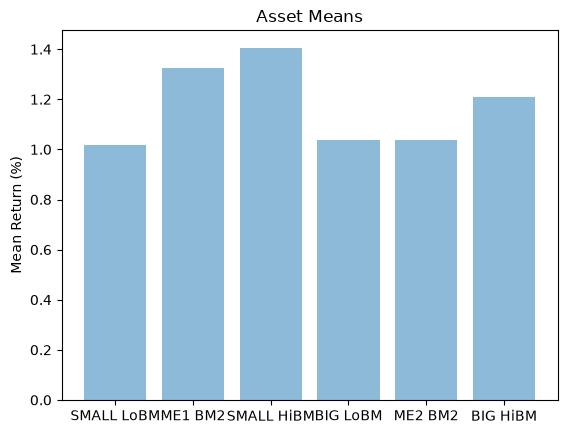

In [2]:
import matplotlib.pyplot as plt
#needed for plot

mean_ret = ret.mean()
print("Asset means:")
print(mean_ret)

y_pos = np.arange(len(mean_ret.index))

plt.bar(y_pos, mean_ret, align='center', alpha=0.5)
plt.xticks(y_pos, mean_ret.index)
plt.ylabel('Mean Return (%)')
plt.title('Asset Means')

plt.show()

We can also look at the sample covariance and correlation matrices for the returns as shown below using Pandas' .cov() and .corr() function. The pairwise correlations are all positive -- and, notably, quite high (roughly 0.7 to 0.96). *Can you explain why this makes sense?* (Hint: all six portfolios are just different slices of the same broad stock market, so they share a great deal of common, market-wide variation.)

The covariance matrix includes (sample) variances on the diagonal. The code below also shows how to extract these variances, and take square roots to get sample standard deviations. These are then plotted as a bar chart.


Covariance matrix:
            SMALL LoBM    ME1 BM2  SMALL HiBM   BIG LoBM    ME2 BM2   BIG HiBM
SMALL LoBM   45.460814  34.282109   33.594087  26.132989  22.712369  25.085187
ME1 BM2      34.282109  29.773806   30.331750  20.223428  20.363498  23.529827
SMALL HiBM   33.594087  30.331750   33.265390  19.386645  21.015158  25.644944
BIG LoBM     26.132989  20.223428   19.386645  22.580372  18.006586  18.548920
ME2 BM2      22.712369  20.363498   21.015158  18.006586  19.606498  20.555563
BIG HiBM     25.085187  23.529827   25.644944  18.548920  20.555563  26.700570
Correlation matrix:
            SMALL LoBM   ME1 BM2  SMALL HiBM  BIG LoBM   ME2 BM2  BIG HiBM
SMALL LoBM    1.000000  0.931819    0.863869  0.815652  0.760753  0.720010
ME1 BM2       0.931819  1.000000    0.963793  0.779959  0.842821  0.834529
SMALL HiBM    0.863869  0.963793    1.000000  0.707360  0.822880  0.860489
BIG LoBM      0.815652  0.779959    0.707360  1.000000  0.855787  0.755428
ME2 BM2       0.760753  0.842821 

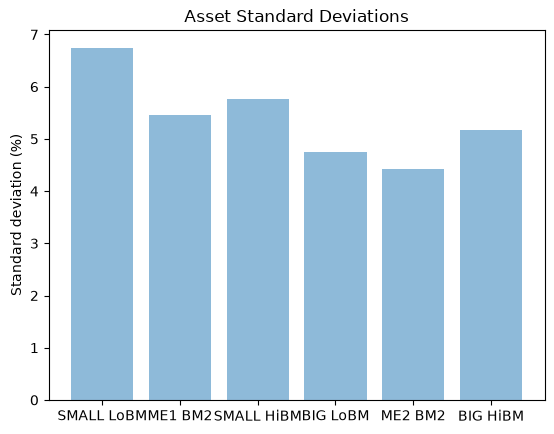

In [3]:
cov_ret = ret.cov()
print("Covariance matrix:")
print(cov_ret)


corr_ret = ret.corr()
print("Correlation matrix:")
print(corr_ret)

#extract the 6 variances from the diagonal of the covariance matrix
var_ret = np.diag(cov_ret)

#take square root to get standard deviations
sd_ret = np.sqrt(var_ret)
print("Standard deviations:")
print(sd_ret)

#Make a bar chart:
plt.bar(y_pos, sd_ret, align='center', alpha=0.5)
plt.xticks(y_pos, mean_ret.index)
plt.ylabel('Standard deviation (%)')
plt.title('Asset Standard Deviations')

plt.show()

### Plotting means versus standard deviation for the assets

Before moving further, let's make a typical (in financial analysis) plot of average returns versus standard deviations for our set of assets:

Here is a nice dataframe for plotting:
                  SD      Mean
SMALL LoBM  6.742463  1.015681
ME1 BM2     5.456538  1.324908
SMALL HiBM  5.767616  1.404966
BIG LoBM    4.751881  1.038656
ME2 BM2     4.427923  1.039172
BIG HiBM    5.167259  1.208225


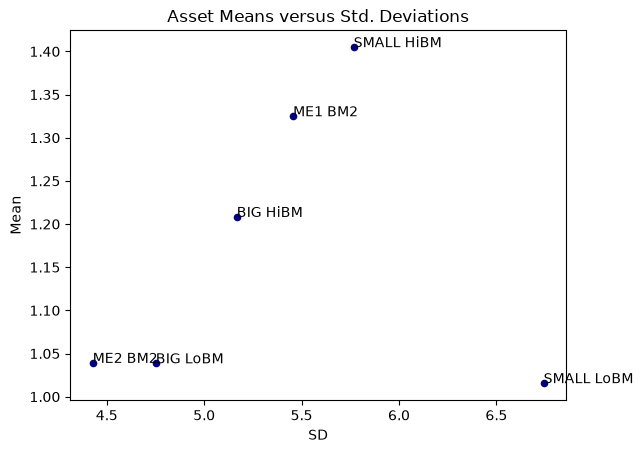

In [4]:
#Make a dataframe

#This line makes a 'dictionary' and then converts the dictionary to a DataFrame (gives nice column names)
temp = {'SD': sd_ret,
        'Mean': mean_ret}
plotdata = pd.DataFrame(temp)
print("Here is a nice dataframe for plotting:")
print(plotdata)

#Now make the plot
ax1 = plotdata.plot.scatter(x = 'SD', y = 'Mean',color="DarkBlue",title="Asset Means versus Std. Deviations")

#This bit of code adds text labels to the points:
for i, txt in enumerate(mean_ret.index):
    ax1.annotate(txt, (plotdata.iloc[i,0], plotdata.iloc[i,1]))

plt.show()

## Benefits of Diversification

With the setting and notation in place, let's briefly review the benefits of diversification. The general idea is that returns on different stocks, or other assets, are generally not perfectly correlated, and contain some degree of *idiosyncratic* variation. By holding positions in multiple assets, these idiosyncratic fluctuations tend to offset, reducing the variance of the portfolio.

To understand diversification benefits more formally, let's look at a special case in which there is **no** diversification benefit. In particular, suppose that the returns to two assets are perfectly positively correlated. This implies that we can write, e.g., $R_{2} = c R_{1}$ for some positive constant $c$. In this case, it is easy to show that the correlation between the returns is $\rho_{1,2} = 1$. 

Now imagine we form a portfolio of these two securities. We can easily compute that:
$\sigma^{2}(R_{p}) = w_{1}^{2} \sigma^{2}_{1} +  w_{2}^{2} \sigma^{2}_{2} + 2 w_{1} w_{2} \rho_{1,2} \sigma_{1} \sigma{2} = (w_{1}\sigma_{1} + w_{2}\sigma_{2})^{2}$

Now take square roots to show that:
$\sigma(R_{p}) = w_{1}\sigma_{1} + w_{2}\sigma_{2}$

In words, the standard deviation of the portfolio return is just the weighted average of the standard deviations of the two (perfectly correlated) assets.

Now, let's assume that the two securities are *not* perfectly correlated, so $-1<\rho_{1,2}<1$. It is now easy to show that:
$\sigma(R_{p}) < w_{1}\sigma_{1} + w_{2}\sigma_{2}$. In words, the standard deviation of the portfolio return is *less than* the weighted combination of the standard deviations of the individual assets. This reflects the benefit of diversification due to the imperfect correlation between the asset returns.

We can generalize this idea to more assets. For example, consider **equal-weighted** portfolios of $N$ assets, so that $w_{n} = 1/N$ for all assets. (For example, the weights are 1/4 for each of 4 stocks.)

When the assets are not redundant (as we will assume), then

$\sigma(R_{p}) < \bar{\sigma}$, where $\bar{\sigma} = (1/N)\sum_{n=1}^{N} \sigma_{n}$, which is just the average standard deviation across the assets. Often, the diversification benefit can be substantial, as we will see below.


The standard deviation assuming (hypothetically) perfect correlation among returns:  5.385613317222713
The standard deviation based on the actual (sample) covariance matrix:  4.98947105418849
The standard deviation assuming (hypothetically) that all returns are pairwise uncorrelated:  0.9474187139470693


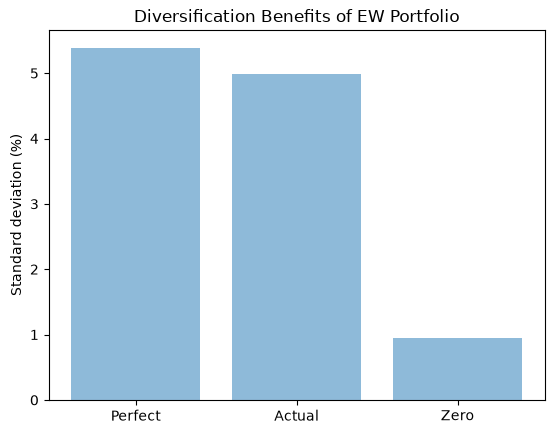

In [5]:
perfectcorr_sd = (1/6)*np.sum(sd_ret)
print("The standard deviation assuming (hypothetically) perfect correlation among returns: ", perfectcorr_sd)

w = (1/6)*np.ones([6,1])

#Note 1: recall that 'cov_ret' is the sample covariance matrix
#Note 2: '@' does matrix multiplocation
#Note 3: the 'squeeze()' bit makes it return a scalar rather than 1 x 1 dataframe
actualcorr_sd = np.sqrt(np.transpose(w)@cov_ret@w).squeeze()
print("The standard deviation based on the actual (sample) covariance matrix: ", actualcorr_sd)

zerocorr_sd =  np.sqrt(np.transpose(w)@np.diag(sd_ret)@w).squeeze()
print("The standard deviation assuming (hypothetically) that all returns are pairwise uncorrelated: ", zerocorr_sd)

#make a simple bar graph to summarize:
barlabels = ["Perfect","Actual","Zero"]
barvals = [perfectcorr_sd,actualcorr_sd,zerocorr_sd]
plt.bar(barlabels, barvals, align='center', alpha=0.5)
plt.ylabel('Standard deviation (%)')
plt.title('Diversification Benefits of EW Portfolio')

plt.show()

## Minimum Variance Portfolio of Risky Assets

A first classic result pertains to the variance-minimizing portfolio of risky assets, or **minimum variance portfolio**.

Mathematically, we want to solve the following problem:
$\min_{w} \sigma^{2}(R_{p}), \hspace{6pt} w^{\prime} 1_{N} = 1$

In words, we want to find the weight vector $w$ (which defines a portfolio) that minimizes the portfolio variance. There is a constraint, which is that the portfolio must be fully invested in the risky assets. (Otherwise, we could just set all the weights to zero, for example, which is uninteresting.)

It can be shown that the solution to this problem is:

$w^{\ast} = \frac{\Sigma^{-1} 1_{N}}{1_{N}^{\prime} \Sigma^{-1} 1_{N}}$.

At the bottom of this workbook, I run through the details of how to demonstrate this solution mathematically using results from calculus and linear algebra. 


### Some intuition: uncorrelated assets

If returns on the assets are all (mutually) uncorrelated, then $\Sigma$ is diagonal, and $\Sigma^{-1}$ is a matrix with the inverse variances on the diagonal. In this case we can write:

$w^{\ast}_{n} = \frac{\sigma^{-2}_{n}}{\sum_{n=1}^{N} \sigma^{-2}_{n}}$. In words, the minimum variance portfolio allocates to each asset in proportion to the "precision" of that assets returns (inverse of variance) as a fraction of the total sum of precisions across the assets.

*Note*: The above result uses the fact that the inverse of a diagonal matrix is another diagonal matrix with diagonal elements that are the inverses of the diagonal elements of the original matrix.

As an important special case, suppose there are just 2 assets with uncorrelated returns. Then the minimum variance portfolio weights are:
$w^{\ast}_{1} = \frac{\sigma^{-2}_{1}}{\sigma^{-2}_{1} + \sigma^{-2}_{2}}$ and $w^{\ast}_{2} = \frac{\sigma^{-2}_{2}}{\sigma^{-2}_{1} + \sigma^{-2}_{2}}$. Basically, the greater asset 1's variance relative to asset 2's variance, the less the investor allocates to asset 1, and vice versa. With a bit of algebra, we can express the optimal allocations equivalently in terms of variances (rather than precisions) as follows:

$w^{\ast}_{1} = \frac{\sigma^{2}_{2}}{\sigma^{2}_{1} + \sigma^{2}_{2}}$ and $w^{\ast}_{2} = \frac{\sigma^{2}_{1}}{\sigma^{2}_{1} + \sigma^{2}_{2}}$.

### More Intuition: 2 imperfectly correlated assets

For more intuition, let's consider the case of two potentially correlated risky assets. By working out the optimal weights formula for this case, we can show that:
$w^{\ast}_{1} =\frac{\sigma^{2}_{2} - \sigma_{1,2}}{\sigma^{2}_{1} + \sigma^{2}_{2} -2 \sigma_{1,2}}$ and $w^{\ast}_{2} =\frac{\sigma^{1}_{1} - \sigma_{1,2}}{\sigma^{2}_{1} + \sigma^{2}_{2} -2 \sigma_{1,2}}$

Now the minimum variance weights depend on the correlation as well as the standard deviations. You can interpret the numerator as measuring the variance of the *other* risky asset corrected for the covariance effect. All else equal, the larger this is, the more we allocate to the asset.


### Taking it to the data
Below, we compute the minimum variance portfolio weights for our assets and the corresponding mean and standard deviation of returns to the minimum variance portfolio:

Min variance portfolio weights:  [[-0.76331425]
 [ 0.94259237]
 [-0.12500185]
 [ 0.64080583]
 [ 0.541937  ]
 [-0.23701909]]
Check that the portfolio weights sum to one:  [1.]
The mean return for the minimum variance portfolio equals  1.2403114063506326
The standard deviation of the return on the minimum variance portfolio equals  4.064851847701515


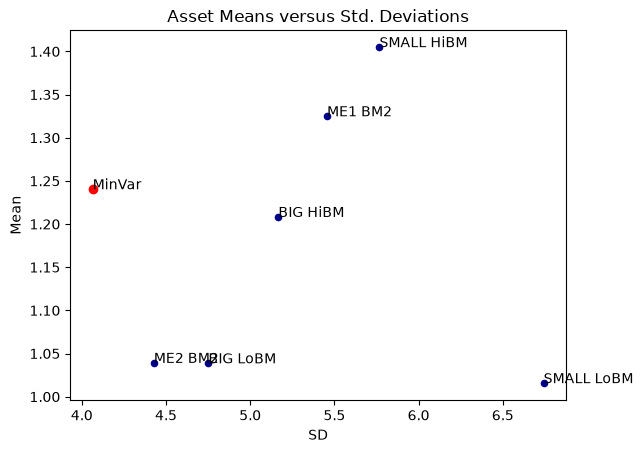

In [6]:
#get the covariance matrix as a matrix in Python
covmat = np.asarray(cov_ret)
#invert it and store inverse covariance matrix
invcovmat = np.linalg.inv(covmat)

#create a vector of ones
onevec = np.ones((6,1), dtype=int)
#print(onevec)

#Now apply the formula from the markdown cell above
numer = np.matmul(invcovmat,onevec)
denomin = np.matmul(np.transpose(onevec),numer)
# an equivalent way to do matrix multiplication
numer = invcovmat @ onevec
denomin = np.transpose(onevec)@numer

wminvar = numer / denomin
print("Min variance portfolio weights: ", wminvar)

print("Check that the portfolio weights sum to one: ", sum(wminvar))

minvarmean = (np.transpose(wminvar)@mean_ret).item()  # .item() -- pandas/numpy matmul with a length-6 Series can return a length-1 array rather than a bare scalar
print("The mean return for the minimum variance portfolio equals ", minvarmean)

minvarsd = np.sqrt(np.transpose(wminvar)@covmat@wminvar).item()
print("The standard deviation of the return on the minimum variance portfolio equals ", minvarsd)

#Now let's make an updated plot that adds the min variance portfolio
ax1 = plotdata.plot.scatter(x = 'SD', y = 'Mean',color="DarkBlue",title="Asset Means versus Std. Deviations")

#This bit of code adds text labels to the points:
for i, txt in enumerate(mean_ret.index):
    ax1.annotate(txt, (plotdata.iloc[i,0], plotdata.iloc[i,1]))
#Add Min var portfolio
plt.scatter(minvarsd,minvarmean,color = "Red")
plt.annotate("MinVar",(minvarsd,minvarmean))

plt.show()

## Minimum-variance frontier

We have reviewed how to obtain the variance minimizing portfolio, but, as pointed out previously, this does not take into account the average returns of the available assets. In principal, investors should care about the means of the asset returns as well as their variances (and covariances).

A standard way to incorporate both dimensions of asset performance is to form "Mean-variance efficient portfolios". The idea is as follows. For each possible target mean (average) return, we solve for the variance-minimizing portfolio weights. In contrast to the *global* minimum variance portfolio (solution above), in this case the solution changes as we change the target average return of the portfolio. 

Mathematically, the problem can be written as:

$\min_{w} w^{\prime}\Sigma w, \hspace{6pt} \text{ subject to: } w^{\prime} \mu = m,  \hspace{6pt} w^{\prime} 1_{N} = 1$

In order to state the mathematical solution to this problem, it is convenient to introduce the following definitions:

$A = 1_{N}^{\prime}\Sigma^{-1}1_{N}$

$B = 1_{N}^{\prime}\Sigma^{-1}\mu = \mu^{\prime} \Sigma^{-1} 1_{N}$

$C = \mu^{\prime}\Sigma^{-1}\mu$

$\Delta = AC-B^{2}$

Note: each of the above are *scalars*

Now, given a particular target mean $m$, the corresponding minimum achievable standard deviation can be shown to be (see details at the bottom of this notebook if you are interested):

$\sigma(m) = \sqrt{\frac{Am^{2} - 2Bm + C}{\Delta}}$

This is a *hyperbola* in mean variance space. More loosely, it is often referred to as the mean-variance "bullet" curve.

The following Python code computes the A, B, C, and $\Delta$ defined above and then implements the formula for our six size/book-to-market portfolios. Then, there is some code that produces a plot of the "bullet curve" for these portfolios.

Standard deviations:  [6.26035686 6.2219347  6.18368842 6.1456213  6.1077367  6.07003803
 6.03252878 5.99521249 5.95809281 5.92117342 5.8844581  5.84795068
 5.81165509 5.77557532 5.73971545 5.70407961 5.66867203 5.63349702
 5.59855896 5.56386231 5.52941163 5.49521152 5.46126671 5.42758199
 5.39416221 5.36101235 5.32813743 5.29554259 5.26323301 5.23121399
 5.19949089 5.16806918 5.13695436 5.10615206 5.07566797 5.04550784
 5.01567754 4.98618297 4.95703013 4.92822509 4.89977397 4.87168298
 4.84395838 4.81660651 4.78963374 4.76304652 4.73685134 4.71105473
 4.68566329 4.66068364 4.63612242 4.61198632 4.58828206 4.56501637
 4.54219597 4.51982761 4.49791805 4.47647401 4.45550222 4.43500937
 4.41500214 4.39548716 4.37647101 4.35796022 4.33996126 4.32248053
 4.30552432 4.28909888 4.2732103  4.25786462 4.24306771 4.22882533
 4.21514312 4.20202653 4.18948089 4.17751133 4.16612282 4.15532015
 4.14510788 4.1354904  4.12647185 4.11805619 4.1102471  4.10304806
 4.09646228 4.09049272 4.08514208 4.0804

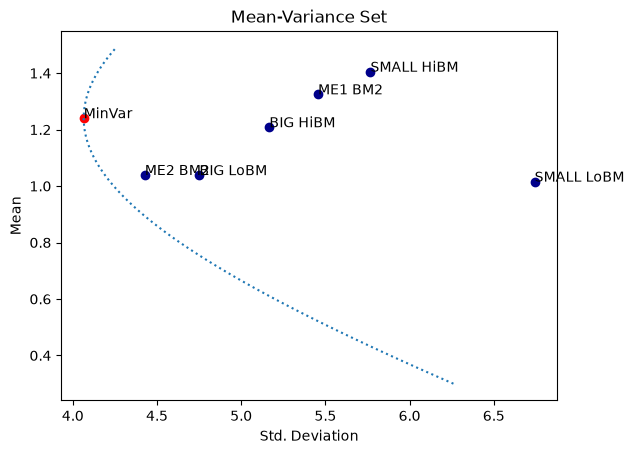

In [7]:
onevec = np.matrix(np.ones([6,1]))
means = np.transpose(np.matrix(mean_ret))

# code up the constants we need
A = np.transpose(onevec)@invcovmat@onevec
B = np.transpose(onevec)@invcovmat@means
C = np.transpose(means)@invcovmat@means
#make scalars for convenience
A = A.item()
B = B.item()
C = C.item()
Delt = A*C-B**2

#This sets out the range of potential mean returns (monthly) we want to consider -- mostly used for plot
minm = 0.3
maxm = 1.5
stepv = 0.01
#mrange below is a vector of all of the means at which we want to compute the minimum variance/std dev.
mrange = np.arange(minm,maxm,stepv)
#print(mrange)

#compute the variance and standard deviation for each m using the key formula
varm = (A*mrange**2 - 2*B*mrange + C)/Delt
sdm = np.sqrt(varm)
print("Standard deviations: ", sdm)

#Now plot the MV efficient set
plt.plot(sdm, mrange, linestyle = 'dotted')
plt.xlabel("Std. Deviation")
plt.ylabel("Mean")
plt.title("Mean-Variance Set")
plt.scatter(plotdata['SD'],plotdata['Mean'],color="DarkBlue")
#Add individual asset labels
#This bit of code adds text labels to the points:
for i, txt in enumerate(mean_ret.index):
    plt.annotate(txt, (plotdata.iloc[i,0], plotdata.iloc[i,1]))

#Add Min var portfolio
plt.scatter(minvarsd,minvarmean,color = "Red")
plt.annotate("MinVar",(minvarsd,minvarmean))

plt.show()

## Tangency portfolio and maximum Sharpe ratio

We have discussed the (global) minimum variance portfolio. But this portfolio ignores means, and investors presumably should care about means. This raises the natural question: *What is the best portfolio of risky assets?* If we are willing to assume that a risk-free investment option is available, i.e., the return on a Treasury-bill held to maturity or a savings account option, then we can arrive at a reasonable answer to this question.

One potentially reasonable criterion is to select the portfolio that provides the highest **Sharpe ratio**, or reward per unit of risk. Recall that the definition of the Sharpe ratio for a portfolio is:

$SR(R_{p}) = \frac{E(R_{p}) - R_{f}}{\sigma(R_{p})}$, where $R_{p}$ is a (risky) portfolio return, and $R_{f}$ is the risk-free rate. 

The quantity $E(R_{p}) - R_{f}$ is the **risk premium** for the portfolio: the extra return on average relative to the risk-free rate that the risky portfolio earns, presumably as compensation for bearing the risk. Thus, the Sharpe ratio equals the risk premium for the portfolio return (a measure of reward) divided by the standard deviation of the portfolio return (the relevant measure of risk in this setting).

Recall also that if an investor splits wealth between a risky portfolio and the risk-free asset, the Sharpe ratio earned is the same irrespective of what proportion of wealth is allocated to the risky asset. This is because, letting $\alpha$ denote the fraction of wealth in the risky asset portfolio, we have:

$SR(\alpha R_{p} + (1-\alpha)R_{f}) = \frac{E(\alpha R_{p} + (1-\alpha)R_{f}) - R_{f}}{\sigma(\alpha R_{p} + (1-\alpha)R_{f})}$

$ = \frac{\alpha(E(R_{p})-R_{f})} {\alpha \sigma(R_{p})} = \frac{(E(R_{p})-R_{f})} {\sigma(R_{p})} $

Graphically, as we move from $\alpha = 0$ (all risk-free) to $\alpha=1$ we trace out points on a line in the mean-standard deviation graph connecting the risk-free return (on the y-axis) with the mean-standard deviation plot for the risky asset portfolio. (If we allow *leveraged* portfolios, so that $\alpha > 1$ then we get points on the same line extending beyond the original portfolio point.) **Importantly, the slope of this line equals the Sharpe ratio for all portfolios on the line.**

The **tangency portfolio** is so-named because it is the portfolio that is fully invested in risky assets (on the MV bullet) that gives the highest possible Sharpe ratio when combined with the risk-free option. Graphically, the line connecting the risk-free rate with this portfolio is just tangent to the MV bullet curve. 

Making the definition $\mu_{e} = \mu - R_{f}1_{N}$ (the vector of average excess returns or risk premiums for the risky assets), the formula for the tangency portfolio is:

$w^{\ast} = \frac{1}{1_{N}^{\prime}\Sigma^{-1}\mu_{e}} \Sigma^{-1} \mu_{e}$

It turns out that we can write the expected return and standard deviation of the tangency portfolio return using the same constants defined above:

$E(R^{\ast}) = \frac{C - BR_{f}}{B - AR_{f}}$

$\sigma(R^{\ast}) = \sqrt{\frac{D}{(B-AR_{f})^{2}}}$, where $D = \mu_{e}^{\prime}\Sigma^{-1}\mu_{e}$ and $A,B,C$ are defined as above.


The Python code that follows determines the tangency portfolio weights for our example with six size/book-to-market portfolios.


Tangency portfolio weights:  [-2.07924021  2.70899304  0.20651077  1.29112931 -0.85608939 -0.27130352]
Expected return for tangency portfolio:
1.8910818186398606
Standard deviation for tangency portfolio:
5.232677242580628


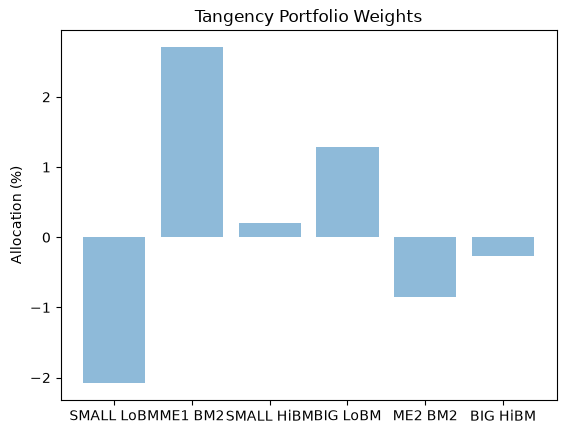

In [8]:
#Set risk-free rate. The interpretation here is 0.25% per month, which is 3% annually
Rf = 0.25

#compute risk premium estimates for the assets
mu_e = mean_ret - Rf

norm_scalar = np.transpose(onevec)@invcovmat@mu_e
wtang = (1/norm_scalar)*invcovmat@mu_e
print("Tangency portfolio weights: ", wtang)

tangmean = (C - B*Rf)/(B-A*Rf)
print("Expected return for tangency portfolio:")
print(tangmean)

D = np.transpose(mu_e)@invcovmat@mu_e
tangvar = D/(B-A*Rf)**2
tangsd = np.sqrt(tangvar)
print("Standard deviation for tangency portfolio:")
print(tangsd)

#Plot the weights in the tangency portfolio

plt.bar(np.arange(0,6), wtang, align='center', alpha=0.5)
plt.xticks(np.arange(0,6), mean_ret.index)
plt.ylabel('Allocation (%)')
plt.title('Tangency Portfolio Weights')

plt.show()

### A Concern
The previous plot should seem a bit concerning. The tangency portfolio takes a large short position in SMALL LoBM (small-cap growth, roughly -208\% of wealth), financing an even larger long position in ME1 BM2 (roughly +271\%), on top of smaller long and short positions elsewhere. *Why is this?*

Look back at the correlation matrix: SMALL LoBM and ME1 BM2 are correlated at about 0.93 -- nearly redundant exposures. When two assets are this highly correlated, the tangency-portfolio formula can turn a small difference in their *estimated* average returns (1.02\% versus 1.32\% per month here) into a large, offsetting long/short "relative value" bet between them, rather than a genuine diversification decision. Economically, the optimizer is effectively borrowing cheaply in the lower-estimated-return asset to lever into its almost-identical, higher-estimated-return twin.

*Why is this a concern?* It is potentially concerning because those average returns are just estimates, not the true means, and are subject to substantial sampling error -- and the more correlated two assets are, the more sensitive the optimal weights are to small errors in their relative means. Thus, intuitively, the concern is that our portfolio weights are "overreacting": aggressively shorting one portfolio and going very long a nearly-identical one, in a way that could easily be driven by noise in the data rather than a genuine, exploitable return difference.


## Putting things together: a recap figure

Let us now summarize all of the prior computations in the form of a figure that plots the MV efficient set, along with the minimum variance and tangency portfolios, and shows the maximum Sharpe ratio obtainable from any combination of the tangency portfolio with the risk-free option.



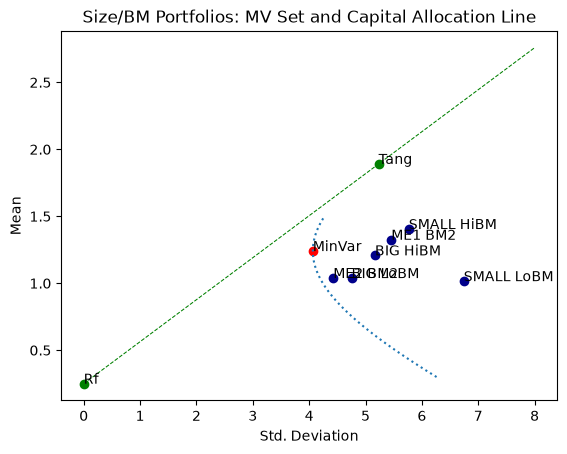

In [9]:
#Start by re-plotting the MV set (same code as before)
plt.plot(sdm, mrange, linestyle = 'dotted')
plt.xlabel("Std. Deviation")
plt.ylabel("Mean")
plt.title("Size/BM Portfolios: MV Set and Capital Allocation Line")
plt.scatter(plotdata['SD'],plotdata['Mean'],color="DarkBlue")
#Add individual asset labels
#This bit of code adds text labels to the points:
for i, txt in enumerate(mean_ret.index):
    plt.annotate(txt, (plotdata.iloc[i,0], plotdata.iloc[i,1]))
#Add Min var portfolio
plt.scatter(minvarsd,minvarmean,color = "Red")
plt.annotate("MinVar",(minvarsd,minvarmean))
#Add Tangency portfolio, Rf, and 'capital allocation line' connecting them
plt.scatter(tangsd,tangmean,color = "Green")
plt.annotate("Tang",(tangsd,tangmean))
#Add Risk-free
plt.scatter(0,Rf,color="Green")
plt.annotate("Rf",(0,Rf))
#Now plot the 'capital-market line' connecting Rf and the tangency portfolio
#First compute the SR of the Tangency portfolio
tangsr = (tangmean-Rf)/tangsd
xmax = max(plotdata['SD'].max(), tangsd) * 1.3
yvals = Rf + tangsr*np.arange(0,xmax)
plt.plot(np.arange(0,xmax),yvals,linestyle='--',color="Green",linewidth=0.75)

plt.show()

## Python's PyPortfolioOpt Package

We have developed all of the portfolio optimization results and code using relatively basic Python (generally only the numpy and pandas modules).

Because portfolio allocation is an important task in the investment world, people have developed specialized Python modules that automate some of the tasks we coded up "by hand" in this example. 

Perhaps the best known of these is the ["PyPortfolioOpt" package](https://pyportfolioopt.readthedocs.io/en/latest/index.html)

There are pros and cons associated with using this module/package.

Pros:
1. Easy commands to do things like generate the efficient frontier
2. Alternative ways of specifying the key inputs (means, covariances) including various "shrinkage" approaches that deal with estimation error
3. Extensions to other ways of measuring risk beyond variance (e.g., "semi-variance" that focuses only on downside variation)


Cons:
1. Requires C++ to work, so not only do you need to install the module (a "pip install " statement) you will likely need to have C++ installed.
2. Relies on several other Python modules (including "cvxopt" that does convex optimization) 
3. Need to be careful to understand the documentation so you know exactly what you are doing

As an illustration of the last con (#3), the default method in this package will impose non-negativity constraints on the underlying assets/stocks. This differs from our assumptions, where we allowed shorting behavior. The additional constraint is realistic for many investors for whom it is difficult to actually take short positions (or whether they are forbidden as in most mutual funds). However, the corresponding problem is different and more difficult to solve (hence the convex optimization module that is required).

Due to the "cons" outlined above, I have decided to focus on the simpler "hand-coded" method here relying only on relative standard Python tools. For certain Python projects, it might be worth the investment to install and understand the PyPortfolioOpt module.



## Takeaways

- Diversification reduces risk whenever asset returns are imperfectly correlated. Combining our 6 size/book-to-market portfolios equally weighted produced a standard deviation (about 5.0\%) below the "perfect correlation" benchmark (about 5.4\%), but still far above the (unrealistic) zero-correlation benchmark (under 1\%) -- consistent with these six portfolios being highly correlated (0.7-0.96), since they're all just different slices of the same broad stock market.
- Sorting on size and book-to-market gave us real dispersion in average returns (roughly 1.0\% to 1.4\% per month, reflecting the value premium), which is what makes the mean-variance tradeoff visible in the first place.
- The minimum-variance portfolio and the mean-variance efficient frontier both follow directly from $w'\Sigma w$ and $w'1_N = 1$: closed-form solutions exist, and `numpy`'s `@` operator and `np.linalg.inv` are all that's needed to compute them from data.
- The tangency portfolio maximizes the Sharpe ratio, but plugging *sample* means and covariances into the tangency-portfolio formula produced extreme, hard-to-justify weights here -- a large short position in one portfolio financing an even larger long position in another, highly correlated portfolio. High correlation between two assets amplifies how sensitive the optimal weights are to small estimation errors in their means -- a preview of why mean-variance optimization is harder to use reliably in practice than the clean formulas suggest.
- `PyPortfolioOpt` automates these computations and adds features like shrinkage estimators and short-sale constraints, but understanding the hand-coded version here is what lets you use a package like that (or debug it) with real understanding of what it's doing.

**Where this goes next.** The estimation-error concern raised by the tangency portfolio's extreme weights is not a one-off curiosity -- it's a central, ongoing theme in empirical asset pricing and portfolio choice, and future notebooks return to it directly.

## Additional Material

This appendix collects the derivations that were stated without proof in the main text above: the closed-form solution for the minimum-variance portfolio, and the corresponding derivation of the mean-variance efficient set.

### Solution of minimum variance portfolio problem

**Warning: this derivation uses constrained (Lagrangian) optimization and matrix calculus that go beyond what's been covered in this course so far -- feel free to skip it.**

Let's plug in the definition of the portfolio variance (as a function of weights) to make things clearer. The problem can be stated as:

$\min_{w} w^{\prime}\Sigma w, \hspace{6pt} w^{\prime} 1_{N} = 1$

To solve the problem, we can apply results from (constrained) optimization in calculus. Specifically, form the "Lagrangian" by substracting a parameter $\lambda$ times the deviation of the constraint from 1:

$L = w^{\prime}\Sigma w - \lambda  (w^{\prime} 1_{N} - 1)$

Now differentiate with respect to $w$ and set the result to zero. Here we use a result from matrix algebra/calculus, which is that the derivative of $w^{\prime}\Sigma w$ with respect to $w$ equals $\Sigma w$:

$0 = \Sigma w^{\ast} - \lambda 1_{N} $, where $w^{\ast}$ is the optimal weights

Now solve for $w^{\ast}$ by inverting the covariance matrix:
$ w^{\ast}=\lambda \Sigma^{-1} 1_{N}$. 

Finally, to get rid of the multiplier $\lambda$, plug the solution back into the constraint:
$1_{N}^{\prime} w = \lambda 1_{N}^{\prime} \Sigma^{-1} 1_{N} = 1$, so $\lambda = 1/(1_{N}\Sigma^{-1}1_{N})$ and we have:

$w^{\ast} = \frac{\Sigma^{-1} 1_{N}}{1_{N}^{\prime} \Sigma^{-1} 1_{N}}$.

### Derivation of MV Efficient Set

**Warning: as with the previous subsection, this derivation uses Lagrangian optimization and matrix calculus beyond what's been covered so far in this course -- feel free to skip it.**

To derive the MV efficient set, note that the problem we want to solve is:

$\min_{w} w^{\prime}\Sigma w, \hspace{6pt} \text{ subject to: } w^{\prime} \mu = m,  \hspace{6pt} w^{\prime} 1_{N} = 1$

Relative to the previous global minimum variance problem, there is now an extra constraint: it is required that the expected return on the portfolio, which is $w^{\prime} \mu$ mathematically, is equal to a specified target level $m$.

As with the minimum variance problem, form the Langrangian:

$L = w^{\prime} \Sigma w - \lambda  (w^{\prime} 1_{N} - 1) - \gamma (w^{\prime}\mu - m)$

Relative to the MV, there is an additional term and "Lagrange multiplier" in this problem driven by the mean return constraint. Now, take the derivative with respect to $w$ and set to zero:

$0 = \Sigma w^{\ast} - \lambda 1_{N} - \gamma \mu$

Now solve for $w^{\ast}$ by rearranging and multiplying both sides by the inverse of the covariance matrix:

$w^{\ast} = \lambda \Sigma^{-1} 1_{N} + \gamma \Sigma^{-1} \mu$


Now we need to substitute out the Lagrange multipliers. This can be done by substituting the formula for the optimal weights above back into the constraint equations, and then solving. For example, let's take $\lambda$. We have:

$1 = w^{\prime} 1_{N} = (\lambda \Sigma^{-1} 1_{N} + \gamma \Sigma^{-1} \mu)^{\prime} 1_{N} = \lambda(1_{N}^{\prime} \Sigma^{-1} 1_{N})+ + \gamma (\mu^{\prime} \Sigma^{-1} 1_{N})$

Similalry, plugging back into the second (mean) constraint gives:

$m = (\lambda \Sigma^{-1} 1_{N} + \gamma \Sigma^{-1} \mu)^{\prime} \mu = \lambda(\mu^{\prime}\Sigma^{-1}1_{N}) + \gamma(\mu^{\prime}\Sigma^{-1}\mu)$

Now comes a key "trick": we consider the previous two equations as a 'system of equations' in $\lambda$ and $\gamma$:

$\begin{pmatrix}
  1\\ 
  m
\end{pmatrix}  = 
\begin{pmatrix}
  A & B\\ 
  B & C
  \end{pmatrix}  
\begin{pmatrix}
  \lambda\\ 
  \gamma
\end{pmatrix}$, where $A, B, \text{ and } C$ are defined as in the previous cell that contained the main result.

The last step is to solve this $2 \times 2$ equation for $\lambda$ and $\gamma$. This can be done in several ways (using matrix inversion, for example, or "old school" substitution methods from algebra). The solution is

$\lambda = \frac{C - Bm}{\Delta}$

$\gamma = \frac{Am - B}{\Delta}$, where $\Delta = AC-B^{2}$.

Finally, to derive the key "mean-standard deviation" equation, note that the variance of the optimal portfolio is:

$\text{Var}(R^{\prime} w^{\ast}) = (w^{\ast})^{\prime} \Sigma w^{\ast} = (w^{\ast})^{\prime}\Sigma (\lambda \Sigma^{-1} 1_{N} + \gamma \Sigma^{-1} \mu) = \lambda (w^{\ast})^{\prime}1_{n} + \gamma (w^{\ast})^{\prime}\mu = \lambda + \gamma m$, where the last equality follows because of the constraints (portfolio weights sum to one and the average return must equal $m$!).

Now plug in our expressions for $\lambda$ and $\gamma$ to get:
$\text{Var}(w^{\ast}R) = \frac{C - Bm}{\Delta} +  \frac{(Am - B)m}{\Delta} = \frac{Am^{2} -2Bm + C}{\Delta}$. Taking the square root gives us the result that was stated, i.e., the standard deviation of the optimal portfolio, as a function of $m$, is equal to 

$\sigma(m) = \sqrt{\frac{Am^{2} - 2Bm + C}{\Delta}}$
